In [417]:
import pandas as pd
import numpy as np

df = pd.read_csv('D:/DS111/DO AN/Data Preparation/processed_data/final_data.csv')

TARGET_COL = 'y'

X_train = df.drop(columns=[TARGET_COL])
y_train = df[TARGET_COL]

In [418]:
y_train[y_train == 1].shape[0] / y_train.shape[0]

0.11691509182858664

In [419]:
X_train.columns
X_train.drop(columns='job_encode')

,duration_log,balance_log,previous_log,day_encode,age_group_encode,poutcome_encode,contact_encode,default_encode,education_encode,pdays_log,campaign_log,month_encode,balance_flag,pdays_contacted,marital_encode,housing_encode,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed
0,0.430,0.507,-0.425,0.985,4,3,0,0,2.000,-0.468,-0.910,0.966,0,0,1,1,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000
1,-0.161,-0.588,-0.425,0.985,3,3,0,0,1.000,-0.468,-0.910,0.966,0,0,2,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
2,-0.899,-0.604,-0.425,0.985,2,3,0,0,1.000,-0.468,-0.910,0.966,0,0,1,1,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,-0.694,0.203,-0.425,0.985,3,3,0,0,1.000,-0.468,-0.910,0.966,0,0,1,1,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,-0.250,-0.472,-0.425,0.985,2,3,0,0,2.000,-0.468,-0.910,0.966,0,0,1,1,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45079,1.859,-0.145,-0.425,0.998,4,3,0,0,2.000,-0.468,0.446,0.966,0,0,1,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
45080,1.034,0.312,-0.425,0.998,0,3,0,0,0.000,-0.468,-0.117,0.966,0,0,0,0,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000
45081,2.014,1.922,2.173,0.998,0,2,0,0,1.000,2.080,1.238,0.966,0,1,1,0,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000
45082,1.151,-0.229,-0.425,0.998,4,3,1,0,1.000,-0.468,0.882,0.966,0,0,1,0,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [420]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

Phương pháp Elbow được dùng để tìm số lượng cụm K tối ưu trong thuật toán phân cụm (như K-means).
Ý tưởng của nó:

Khi tăng số cụm K, độ lỗi phân cụm (SSE – Sum of Squared Errors) sẽ giảm.

Nhưng khi K lớn đến một mức nào đó, việc tăng thêm cụm không cải thiện nhiều → đường biểu diễn SSE gãy khúc giống như khuỷu tay.

Điểm “khuỷu tay” chính là giá trị K hợp lý nhất.

SSE:

SSE = tổng khoảng cách bình phương từ mỗi điểm đến tâm cụm của nó.

SSE càng thấp → cụm càng chặt → phân cụm càng tốt.

Nhưng K càng lớn thì SSE luôn giảm → nên phải tìm điểm tối ưu chứ không thể chọn bừa.

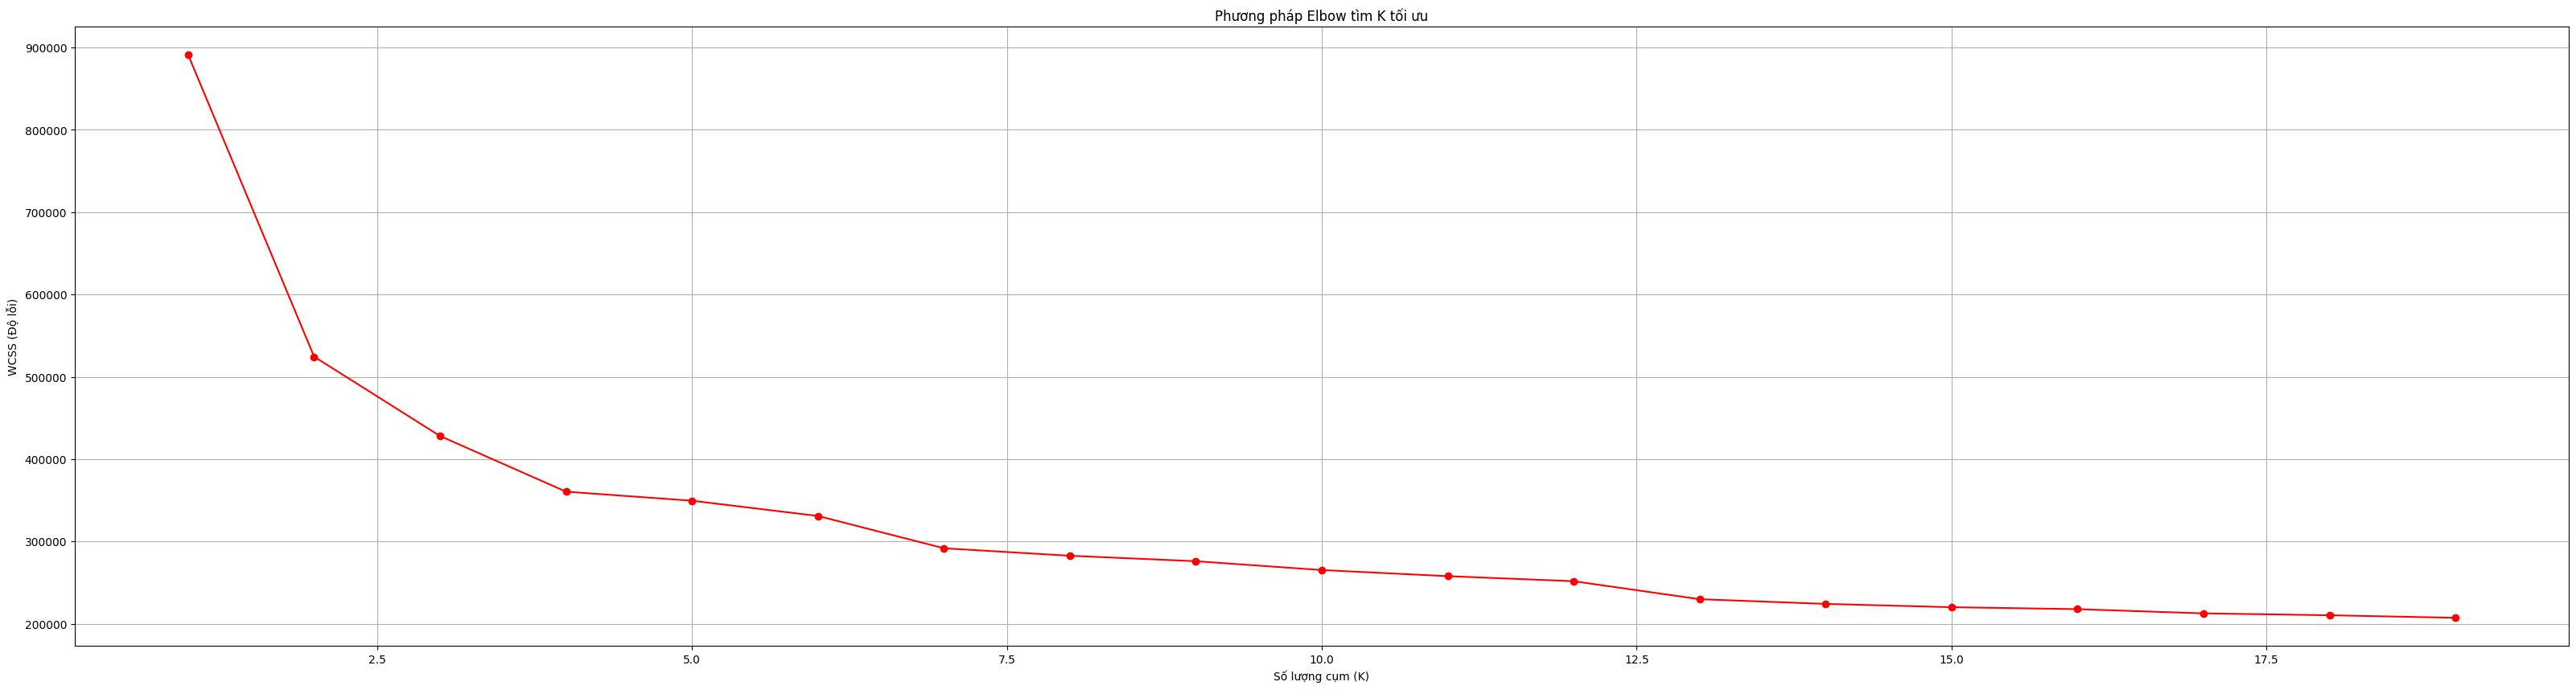

In [421]:
wcss = [] # Within-Cluster Sum of Square
K_range = range(1, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(40,10))
plt.plot(K_range, wcss, marker='o', color='red')
plt.title('Phương pháp Elbow tìm K tối ưu')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('WCSS (Độ lỗi)')
plt.grid(True)
plt.show()

Từ K=1 đến K=2: Độ lỗi giảm cực kỳ mạnh (đường dốc đứng). Điều này có nghĩa là chia làm 2 nhóm tốt hơn hẳn so với gộp chung 1 nhóm.

Từ K=2 đến K=3: Độ lỗi vẫn giảm đáng kể, độ dốc vẫn còn lớn.

Từ K=3 đến K=4: Độ lỗi bắt đầu giảm chậm lại, đường cong bắt đầu thoải dần. Đây chính là vị trí "khuỷu tay".

Từ K=4 trở đi (5, 6, 7...): Đường cong gần như đi ngang, việc chia thêm nhóm không giúp ích nhiều cho việc phân loại nữa mà chỉ làm mô hình phức tạp thêm.
=> Ta thấy rõ “khuỷu tay” tại k từ 4->5

In [422]:
X_train_raw = pd.read_csv('D:\DS111\DO AN\Data Preparation\processed_data\df_train.csv')
X_train_raw.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y', 'age_group', 'balance_log', 'balance_flag', 'duration_log', 'campaign_log', 'pdays_contacted', 'pdays_log', 'previous_log', 'education_encode', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'default_encode', 'housing_encode', 'loan_encode', 'job_encode', 'marital_encode', 'contact_encode', 'poutcome_encode', 'age_group_encode', 'day_encode', 'month_encode'], dtype='object')

Để có thể nhận xét đúng giá trị của mỗi nhóm khách hàng => Sử dụng dataset gốc nhưng đã qua xử lí missing value

In [ ]:
from IPython.display import display

pd.set_option('display.max_columns', None)   
pd.set_option('display.width', 2000)         
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.3f}'.format)

In [424]:
def get_mode(x):
    return x.mode()[0] if not x.mode().empty else np.nan

def analyzed_pattern(X_train, X_train_raw, k):
    df_analyze = X_train_raw.copy()

    binary_cols = ['default', 'housing', 'loan']
    for col in binary_cols:
        df_analyze[col] = df_analyze[col].map({'yes': 1, 'no': 0})

    agg_dict = {
        'age_group': get_mode,
        'age': 'mean',
        'job': get_mode,
        'marital': get_mode,
        'education': get_mode,
        'default': 'mean',
        'balance': 'median',
        'housing': 'mean',
        'loan': 'mean',
          
        'contact': get_mode,
        'day': get_mode,
        'month': get_mode,
        'duration': 'median',
        'campaign': 'median',
        'pdays': 'median',
        'previous': 'median',
        'poutcome': get_mode,
        
        'y': 'mean'
    }

    cols_to_use = list(agg_dict.keys())

    cluster_profile = (
        df_analyze
        .groupby('Cluster')[cols_to_use]
        .agg(agg_dict)
    )

    cluster_profile['Count'] = df_analyze['Cluster'].value_counts()
    cluster_profile = cluster_profile.sort_values(by='y', ascending=False)

    print(f"=== BẢNG ĐẶC ĐIỂM CÁC PATTERN KHÁCH HÀNG (K={k}) ===")
    display(cluster_profile)
    # VẼ PCA 
    try:
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_train)

        plt.figure(figsize=(10,8))
        sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df_analyze['Cluster'], palette='deep', alpha=0.6)
        plt.title('Biểu đồ phân cụm khách hàng (PCA Visualization)')
        plt.xlabel('PCA Component 1')
        plt.ylabel('PCA Component 2')
        plt.legend(title='Cluster')
        plt.show()
    except Exception as e:
        print(f"Lỗi vẽ PCA: {e}")
        print("Gợi ý: Kiểm tra xem X_train đã được Encode và Scale thành số chưa.")


Đã phân cụm xong!
=== BẢNG ĐẶC ĐIỂM CÁC PATTERN KHÁCH HÀNG (K=4) ===


,age_group,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,Count
Cluster,,,,,,,,,,,,,,,,,,,
3,U40,42.262,management,married,secondary,0.008,625.000,0.635,0.137,cellular,18,may,193.000,2.000,195.000,2.000,failure,0.221,5710
0,U40,38.444,technician,married,secondary,0.017,407.000,0.545,0.161,cellular,20,may,181.000,2.000,-1.000,0.000,unknown,0.121,13947
2,U40,44.077,management,married,tertiary,0.019,528.000,0.423,0.141,cellular,20,aug,172.000,2.000,-1.000,0.000,unknown,0.110,11863
1,U40,40.111,blue-collar,married,secondary,0.022,370.000,0.655,0.188,cellular,20,may,180.000,2.000,-1.000,0.000,unknown,0.075,13564


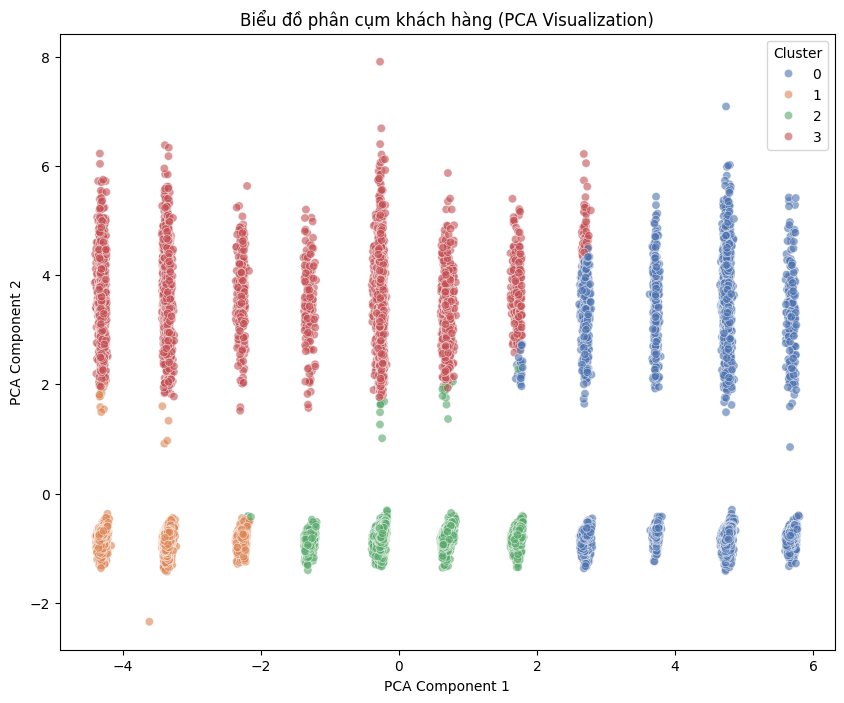

In [425]:
# Khởi tạo và chạy mô hình với K đã chọn
optimal_k = [4]
for k in optimal_k: 
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    y_kmeans = kmeans.fit_predict(X_train)

    # Gán nhãn cụm vào dữ liệu GỐC để phân tích
    X_train_raw['Cluster'] = y_kmeans
    print("Đã phân cụm xong!")
    
    analyzed_pattern(X_train, X_train_raw, k)

=== PHÂN TÍCH BIẾN SỐ (NUMERICAL) ===


C:\Users\Thy\AppData\Local\Temp\ipykernel_9340\3266446138.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=X_train_raw, ax=axes[i], showfliers=False, palette='Set2')
C:\Users\Thy\AppData\Local\Temp\ipykernel_9340\3266446138.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=X_train_raw, ax=axes[i], showfliers=False, palette='Set2')
C:\Users\Thy\AppData\Local\Temp\ipykernel_9340\3266446138.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=X_train_raw, ax=axes[

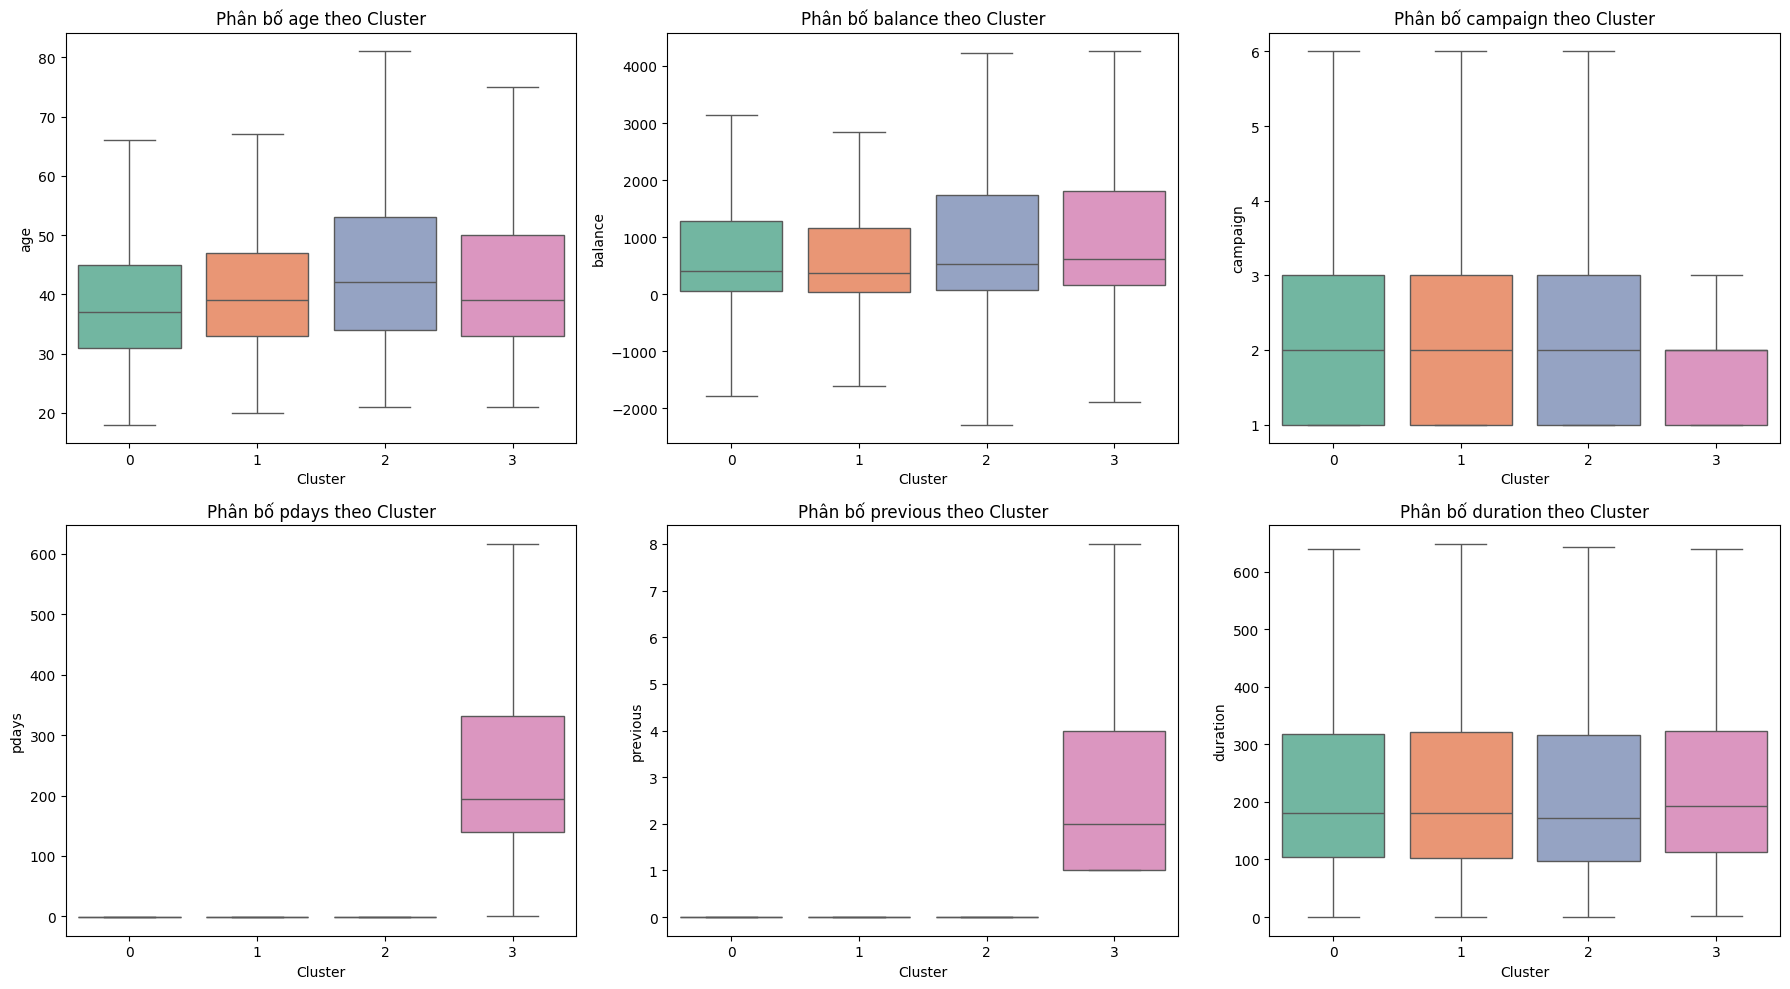

=== PHÂN TÍCH BIẾN PHÂN LOẠI (CATEGORICAL) ===


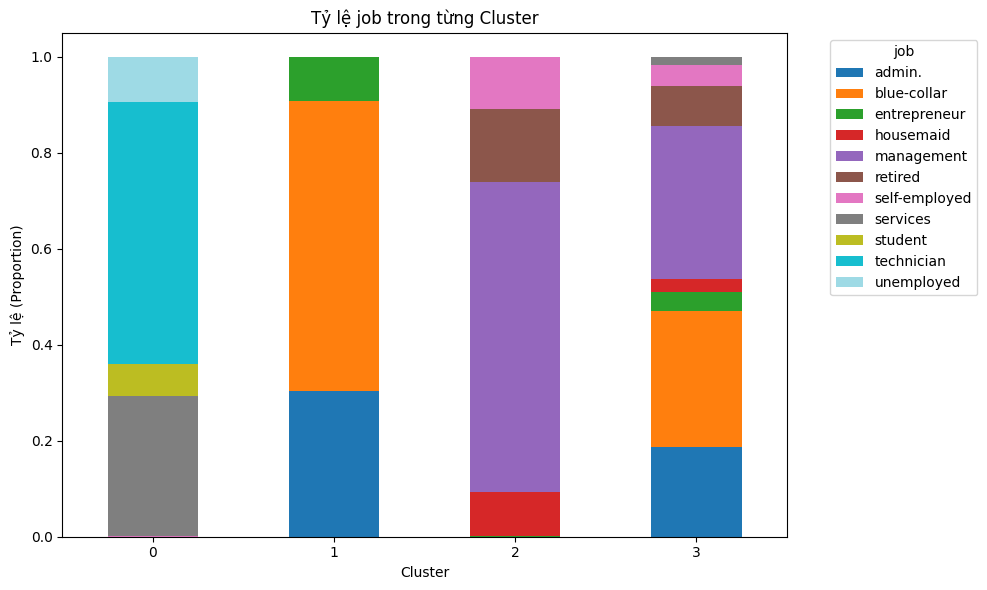

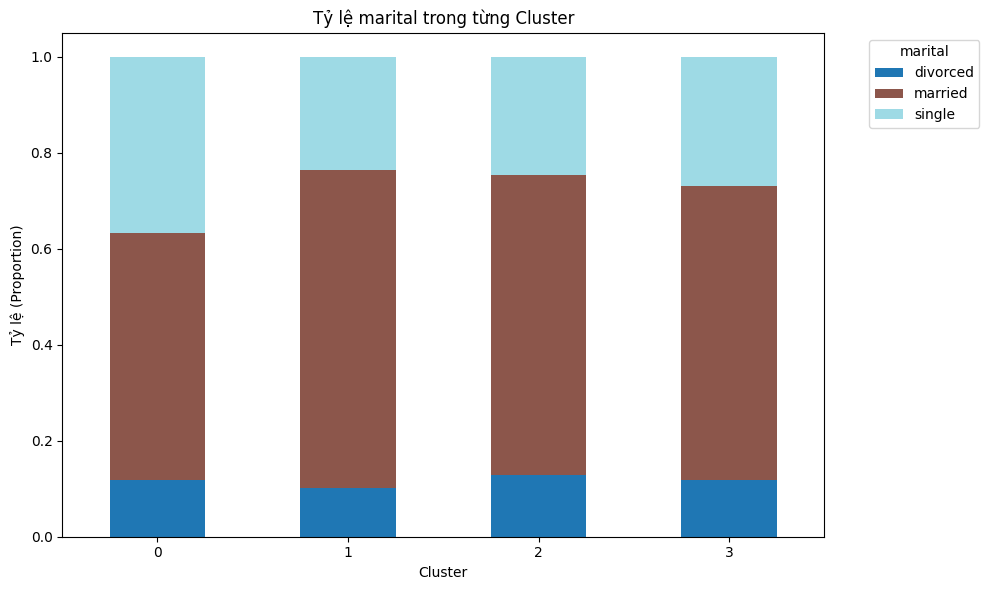

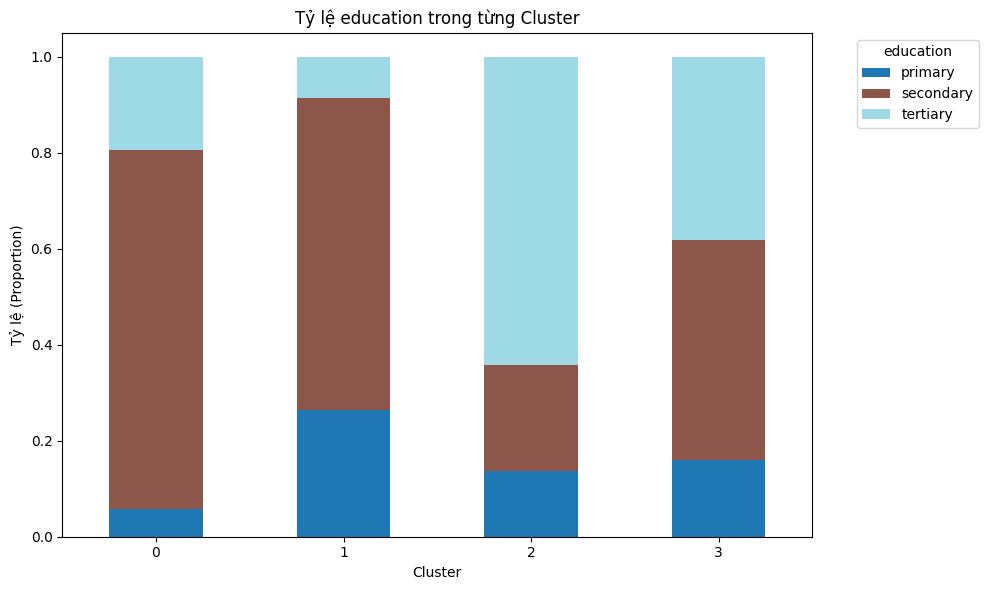

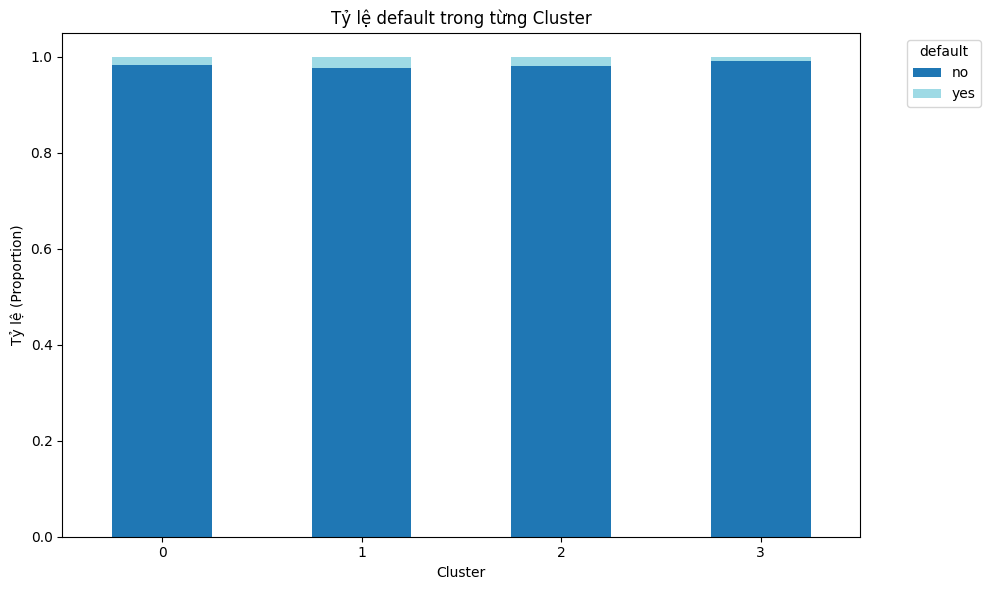

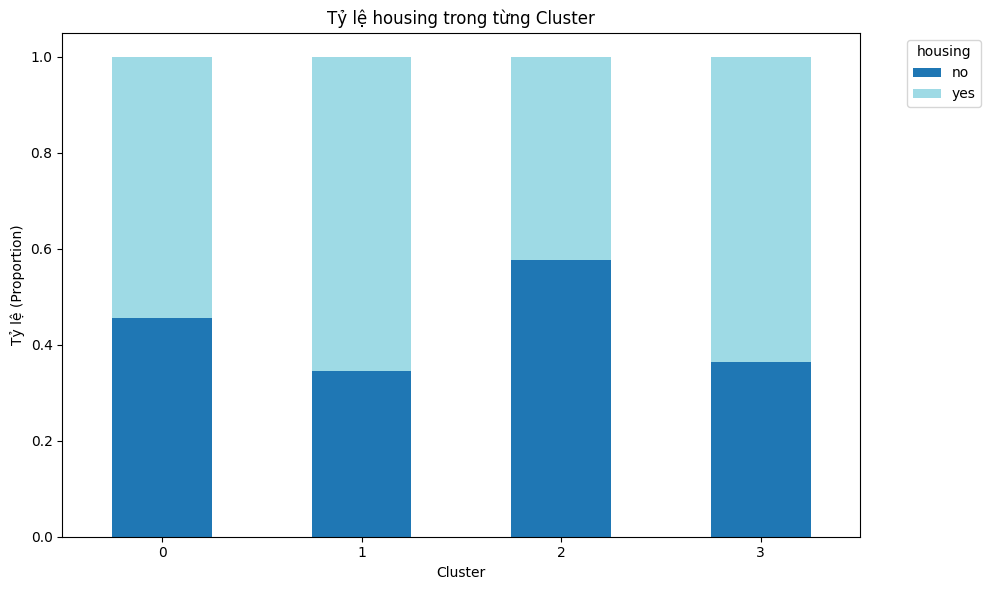

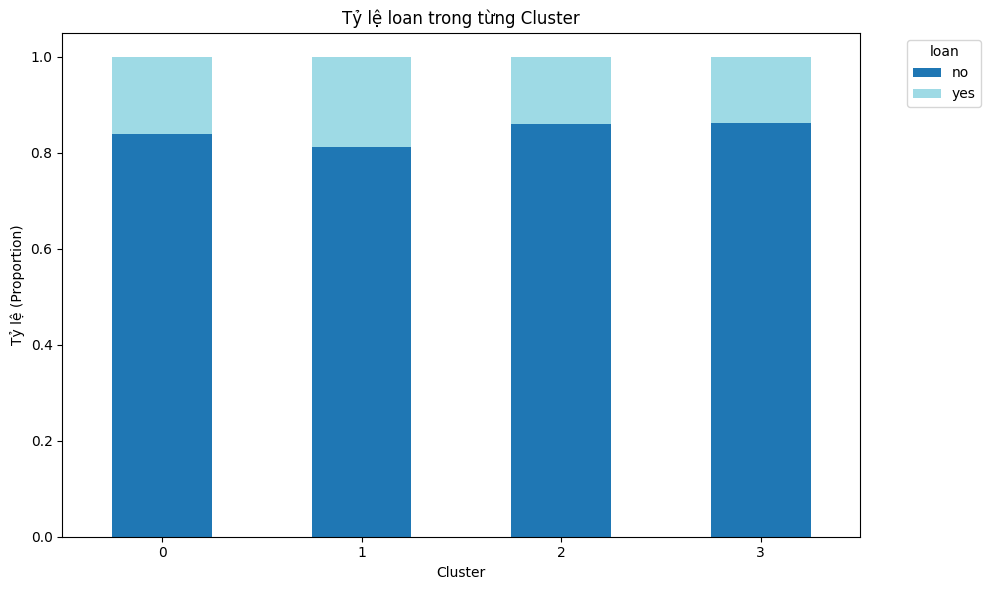

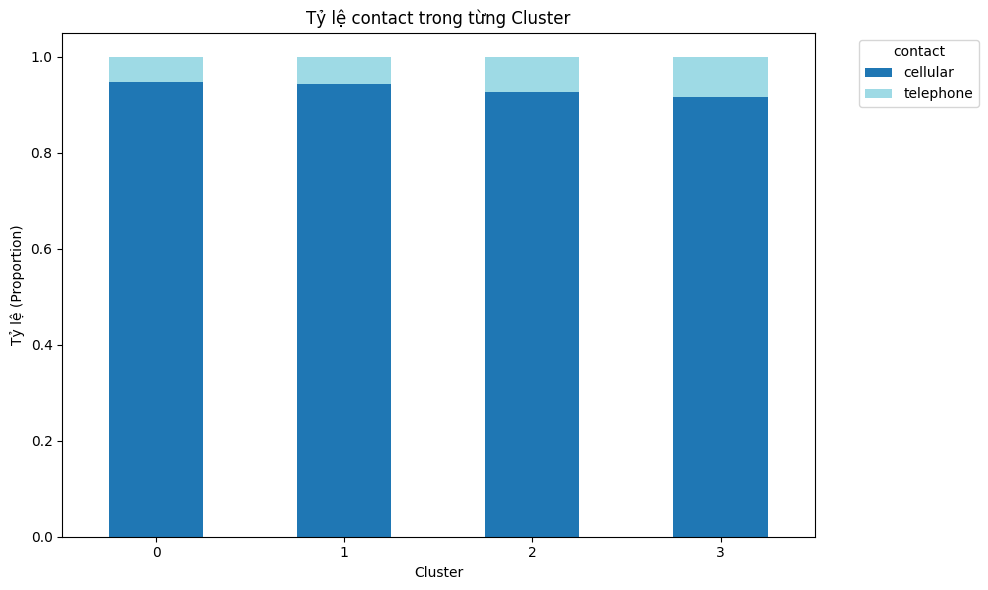

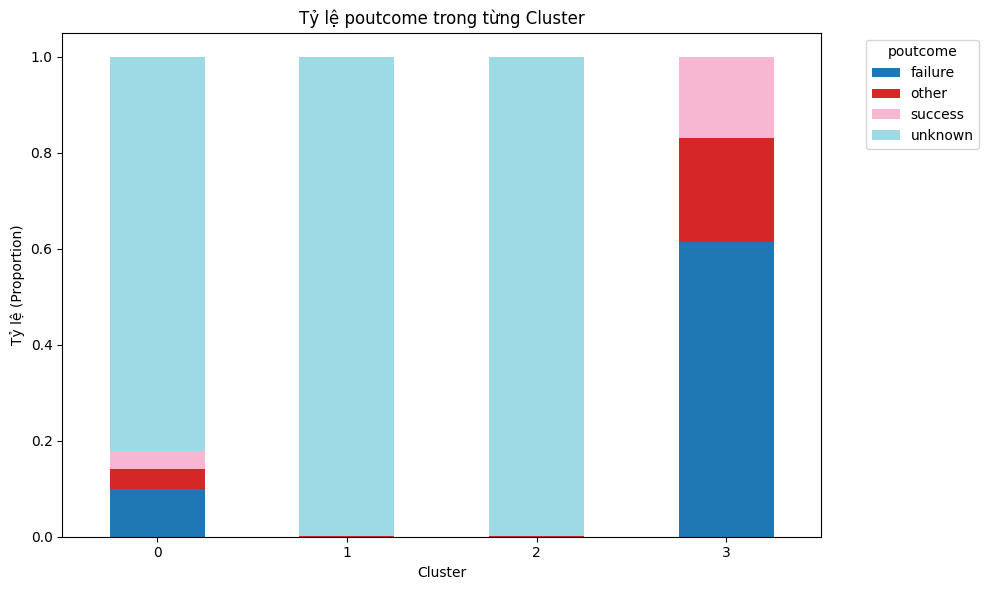

In [426]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# PHÂN LOẠI BIẾN

numerical_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

#vVẼ BIỂU ĐỒ CHO BIẾN SỐ (NUMERICAL) 
print("=== PHÂN TÍCH BIẾN SỐ (NUMERICAL) ===")
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10)) 
axes = axes.flatten()
cols_to_plot = ['age', 'balance', 'campaign', 'pdays', 'previous', 'duration']

for i, col in enumerate(cols_to_plot):
    if i < len(axes):
        sns.boxplot(x='Cluster', y=col, data=X_train_raw, ax=axes[i], showfliers=False, palette='Set2')
        axes[i].set_title(f'Phân bố {col} theo Cluster')
        axes[i].set_xlabel('Cluster')
        axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()


# VẼ BIỂU ĐỒ CHO BIẾN PHÂN LOẠI (CATEGORICAL)
print("=== PHÂN TÍCH BIẾN PHÂN LOẠI (CATEGORICAL) ===")

def plot_stacked_bar(dataframe, cluster_col, feature_col):
    ct = pd.crosstab(dataframe[cluster_col], dataframe[feature_col], normalize='index')
    
    ax = ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
    plt.title(f'Tỷ lệ {feature_col} trong từng Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Tỷ lệ (Proportion)')
    plt.legend(title=feature_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

for col in ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']:
    plot_stacked_bar(X_train_raw, 'Cluster', col)

### TESTING cho Cluster

#### Kiểm chứng tỉ lệ target bằng Z-test cho Cluster

In [427]:
cluster_target = X_train_raw.groupby('Cluster')['y'].agg(['mean','count']).reset_index()
cluster_target.rename(columns={'mean':'yes_ratio','count':'n_samples'}, inplace=True)
print(cluster_target)

   Cluster  yes_ratio  n_samples
0        0      0.121      13947
1        1      0.075      13564
2        2      0.110      11863
3        3      0.221       5710


In [428]:
import statsmodels.api as sm

p_overall = X_train_raw['y'].mean() 

for idx, row in cluster_target.iterrows():
    count = row['n_samples'] * row['yes_ratio']
    nobs = row['n_samples']
    stat, pval = sm.stats.proportions_ztest(count, nobs, value=p_overall, alternative='larger')
    print(f"Cluster {int(row['Cluster'])}: Yes_ratio={row['yes_ratio']:.2%}, Z={stat:.2f}, p-value={pval:.3f}")

Cluster 0: Yes_ratio=12.15%, Z=1.64, p-value=0.050
Cluster 1: Yes_ratio=7.48%, Z=-18.67, p-value=1.000
Cluster 2: Yes_ratio=10.98%, Z=-2.47, p-value=0.993
Cluster 3: Yes_ratio=22.07%, Z=18.91, p-value=0.000


p-value < 0.05 → tỉ lệ Yes trong cluster thực sự cao hơn tổng thể → cluster tiềm năng để trích rule

=> Cluster 3 là cluster tốt nhất, tỉ lệ khách đăng ký cao, ý nghĩa thống kê rõ ràng, nên tập trung khai thác.

In [429]:
for idx, row in cluster_target.iterrows():
    lift = row['yes_ratio'] / p_overall
    coverage = row['n_samples'] / len(X_train_raw)
    print(f"Cluster {int(row['Cluster'])}: Lift={lift:.2f}, Coverage={coverage:.2%}")

Cluster 0: Lift=1.04, Coverage=30.94%
Cluster 1: Lift=0.64, Coverage=30.09%
Cluster 2: Lift=0.94, Coverage=26.31%
Cluster 3: Lift=1.89, Coverage=12.67%


Lift > 1 → cluster tốt hơn tổng thể

Coverage → phạm vi khách hàng trong cluster

Coverage 12.67% hơi nhỏ nhưng bù lại tỉ lệ đăng ký rất cao → nên áp dụng cluster tiềm năng

#### Stability check cluster

In [430]:
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

runs = []
for seed in range(5):
    km = KMeans(n_clusters=4, random_state=seed)
    labels = km.fit_predict(X_train)
    runs.append(labels)

scores = []
for i in range(len(runs)):
    for j in range(i+1,len(runs)):
        scores.append(adjusted_rand_score(runs[i],runs[j]))

print("Mean stability (ARI):", np.mean(scores))

Mean stability (ARI): 0.8794080036428754


ARI gần 1 → cluster ổn định → đáng tin để trích rule bằng Decision Tree

Mean stability (ARI) = 0.879 → cluster ổn định, không phải do random init

Cluster 3 xuất hiện gần như giống nhau trong các lần chạy KMeans khác → đáng tin để khai thác rule

SUMMARY: 

1. Đặc điểm nhân khẩu học & nghề nghiệp

        Age_group / age: chủ yếu U40, tuổi trung bình 42.26 → nhóm khách hàng trưởng thành, kinh nghiệm ổn định.

        Job: chủ yếu management → khách hàng có vị trí quản lý, khả năng thu nhập cao.

        Marital: hầu hết married → có thể ổn định về kinh tế.

        Education: chủ yếu secondary → bằng cấp trung học hoặc tương đương.

2. Tài chính & tín dụng

        Balance: trung vị 625 → mức tiền gửi ngân hàng khá cao.

        Housing: 63.5% có nhà riêng → ổn định tài sản.

        Loan: chỉ 13.7% có khoản vay cá nhân → nợ thấp, khả năng chấp nhận sản phẩm mới cao.

        Default: cực thấp 0.8% → ít rủi ro tín dụng.

3. Hành vi giao dịch / liên hệ

        Contact: chủ yếu cellular → dễ liên hệ qua điện thoại di động.

        Duration: trung vị 193s → cuộc gọi dài hơn các cluster khác → khả năng tương tác tốt.

        Campaign / pdays / previous: số lần tiếp xúc trung bình 2 → khách hàng đã được liên hệ trước nhưng chưa quá nhiều lần → không bị “quá tải” thông tin.

        Poutcome: chủ yếu failure → chưa đăng ký trước đó, còn tiềm năng.

4. Tỉ lệ đăng ký

        Yes_ratio = 22.1% → cao gấp ~2 lần tổng thể (~11%).

        Count = 5710 khách hàng → cluster này đủ lớn để triển khai chiến dịch marketing.

5. Kết luận / Pattern nhận xét

        Cluster 3 là nhóm khách hàng tiềm năng cao, với đặc điểm:

        Tuổi trung bình 42, chủ yếu management, married, secondary education

        Tài chính ổn định: balance cao, ít nợ, có nhà

        Hành vi liên hệ tốt: điện thoại di động, cuộc gọi dài, đã được tiếp xúc trước nhưng chưa đăng ký

        Khả năng đăng ký sản phẩm cao → nên ưu tiên target cluster này cho chiến dịch marketing

        Đây là pattern cluster: bạn có thể dùng thông tin này để trích rule Decision Tree liên quan đến job, age, balance, housing, loan… để triển khai rule-based campaign.

### Rule based on DecisionTree

In [431]:
from sklearn.tree import DecisionTreeClassifier

In [432]:
X_train_raw.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y', 'age_group', 'balance_log', 'balance_flag', 'duration_log', 'campaign_log', 'pdays_contacted', 'pdays_log', 'previous_log', 'education_encode', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'default_encode', 'housing_encode', 'loan_encode', 'job_encode', 'marital_encode', 'contact_encode', 'poutcome_encode', 'age_group_encode', 'day_encode', 'month_encode', 'Cluster'], dtype='object')

In [433]:
cols = [
        'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day', 'month','age_group', 'poutcome',
        'balance_log', 'balance_flag', 'duration_log', 'campaign_log', 'pdays_log', 'previous_log',
        'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
        'job_management', 'job_retired', 'job_self-employed', 'job_services',
        'job_student', 'job_technician', 'job_unemployed','age_group_encode'
    ]

In [434]:
X_new = X_train_raw.drop(columns=cols)

In [435]:
X_new.columns

Index(['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'y', 'pdays_contacted', 'education_encode', 'default_encode', 'housing_encode', 'loan_encode', 'job_encode', 'marital_encode', 'contact_encode', 'poutcome_encode', 'day_encode', 'month_encode', 'Cluster'], dtype='object')

In [436]:
X_new["Cluster"] = kmeans.labels_

In [437]:
cluster_perf = (
    X_new
    .groupby("Cluster")["y"]
    .mean()
    .sort_values(ascending=False)
)

best_cluster = cluster_perf.index[0]

In [438]:
X_best = X_new[X_new["Cluster"] == best_cluster].drop(columns='y')
y_best = X_new[X_new["Cluster"] == best_cluster]['y']

In [439]:
X_best.columns

Index(['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'pdays_contacted', 'education_encode', 'default_encode', 'housing_encode', 'loan_encode', 'job_encode', 'marital_encode', 'contact_encode', 'poutcome_encode', 'day_encode', 'month_encode', 'Cluster'], dtype='object')

In [440]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=42)
dt.fit(X_best, y_best)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=42)

In [441]:
from sklearn.tree import DecisionTreeClassifier, _tree
import statsmodels.api as sm

def extract_rules_and_test(dt, X, y, alpha=0.05):
    """Trích rule từ Decision Tree và tính Yes_ratio, lift, coverage, Z-test"""
    tree = dt.tree_
    feature_names = X.columns
    rules = []

    def recurse(node, rule_conditions):
        if tree.feature[node] != _tree.TREE_UNDEFINED:  # internal node
            name = feature_names[tree.feature[node]]
            threshold = tree.threshold[node]

            # left child
            recurse(tree.children_left[node], rule_conditions + [(name, "<=", threshold)])
            # right child
            recurse(tree.children_right[node], rule_conditions + [(name, ">", threshold)])
        else:  # leaf
            mask = np.ones(len(X), dtype=bool)
            for feat, op, thresh in rule_conditions:
                if op == "<=":
                    mask &= X[feat] <= thresh
                else:
                    mask &= X[feat] > thresh

            subset = X[mask].copy()
            subset['y'] = y[mask]

            if len(subset) == 0:
                return

            yes_ratio = subset['y'].mean()
            n_samples = len(subset)
            count = subset['y'].sum()
            p_overall = y.mean()
            
            # Z-test
            stat, pval = sm.stats.proportions_ztest(count, n_samples, value=p_overall, alternative='larger')
            lift = yes_ratio / p_overall
            coverage = n_samples / len(X)

            rules.append({
                "rule": " AND ".join([f"{f} {op} {thresh:.2f}" for f, op, thresh in rule_conditions]),
                "n_samples": n_samples,
                "yes_ratio": yes_ratio,
                "Z_stat": stat,
                "p_value": pval,
                "lift": lift,
                "coverage": coverage,
                "significant": pval < alpha
            })

    recurse(0, [])
    df_rules = pd.DataFrame(rules)
    df_rules = df_rules.sort_values(by='yes_ratio', ascending=False).reset_index(drop=True)
    return df_rules

In [442]:
df_rule_summary = extract_rules_and_test(dt, X_best, y_best)
display(df_rule_summary)

,rule,n_samples,yes_ratio,Z_stat,p_value,lift,coverage,significant
0,poutcome_encode > 1.50 AND duration > 132.50 AND duration > 214.50 AND housing_encode <= 0.50,389,0.823,31.081,0.000,3.728,0.068,True
1,poutcome_encode <= 1.50 AND duration > 408.50 AND duration > 632.50 AND day_encode <= 0.98,62,0.677,7.694,0.000,3.070,0.011,True
2,poutcome_encode > 1.50 AND duration > 132.50 AND duration > 214.50 AND housing_encode > 0.50,186,0.667,12.903,0.000,3.021,0.033,True
3,poutcome_encode > 1.50 AND duration > 132.50 AND duration <= 214.50 AND pdays <= 185.50,183,0.650,12.187,0.000,2.947,0.032,True
4,poutcome_encode <= 1.50 AND duration > 408.50 AND duration > 632.50 AND day_encode > 0.98,238,0.483,8.105,0.000,2.190,0.042,True
5,poutcome_encode > 1.50 AND duration > 132.50 AND duration <= 214.50 AND pdays > 185.50,58,0.483,3.994,0.000,2.188,0.010,True
6,poutcome_encode <= 1.50 AND duration > 408.50 AND duration <= 632.50 AND housing_encode <= 0.50,148,0.459,5.829,0.000,2.082,0.026,True
7,poutcome_encode > 1.50 AND duration <= 132.50 AND pdays <= 99.00,57,0.386,2.564,0.005,1.749,0.010,True
8,poutcome_encode <= 1.50 AND duration <= 408.50 AND housing_encode > 0.50 AND pdays > 383.00,69,0.362,2.448,0.007,1.642,0.012,True
9,poutcome_encode <= 1.50 AND duration <= 408.50 AND housing_encode <= 0.50 AND duration > 153.50,647,0.297,4.237,0.000,1.345,0.113,True


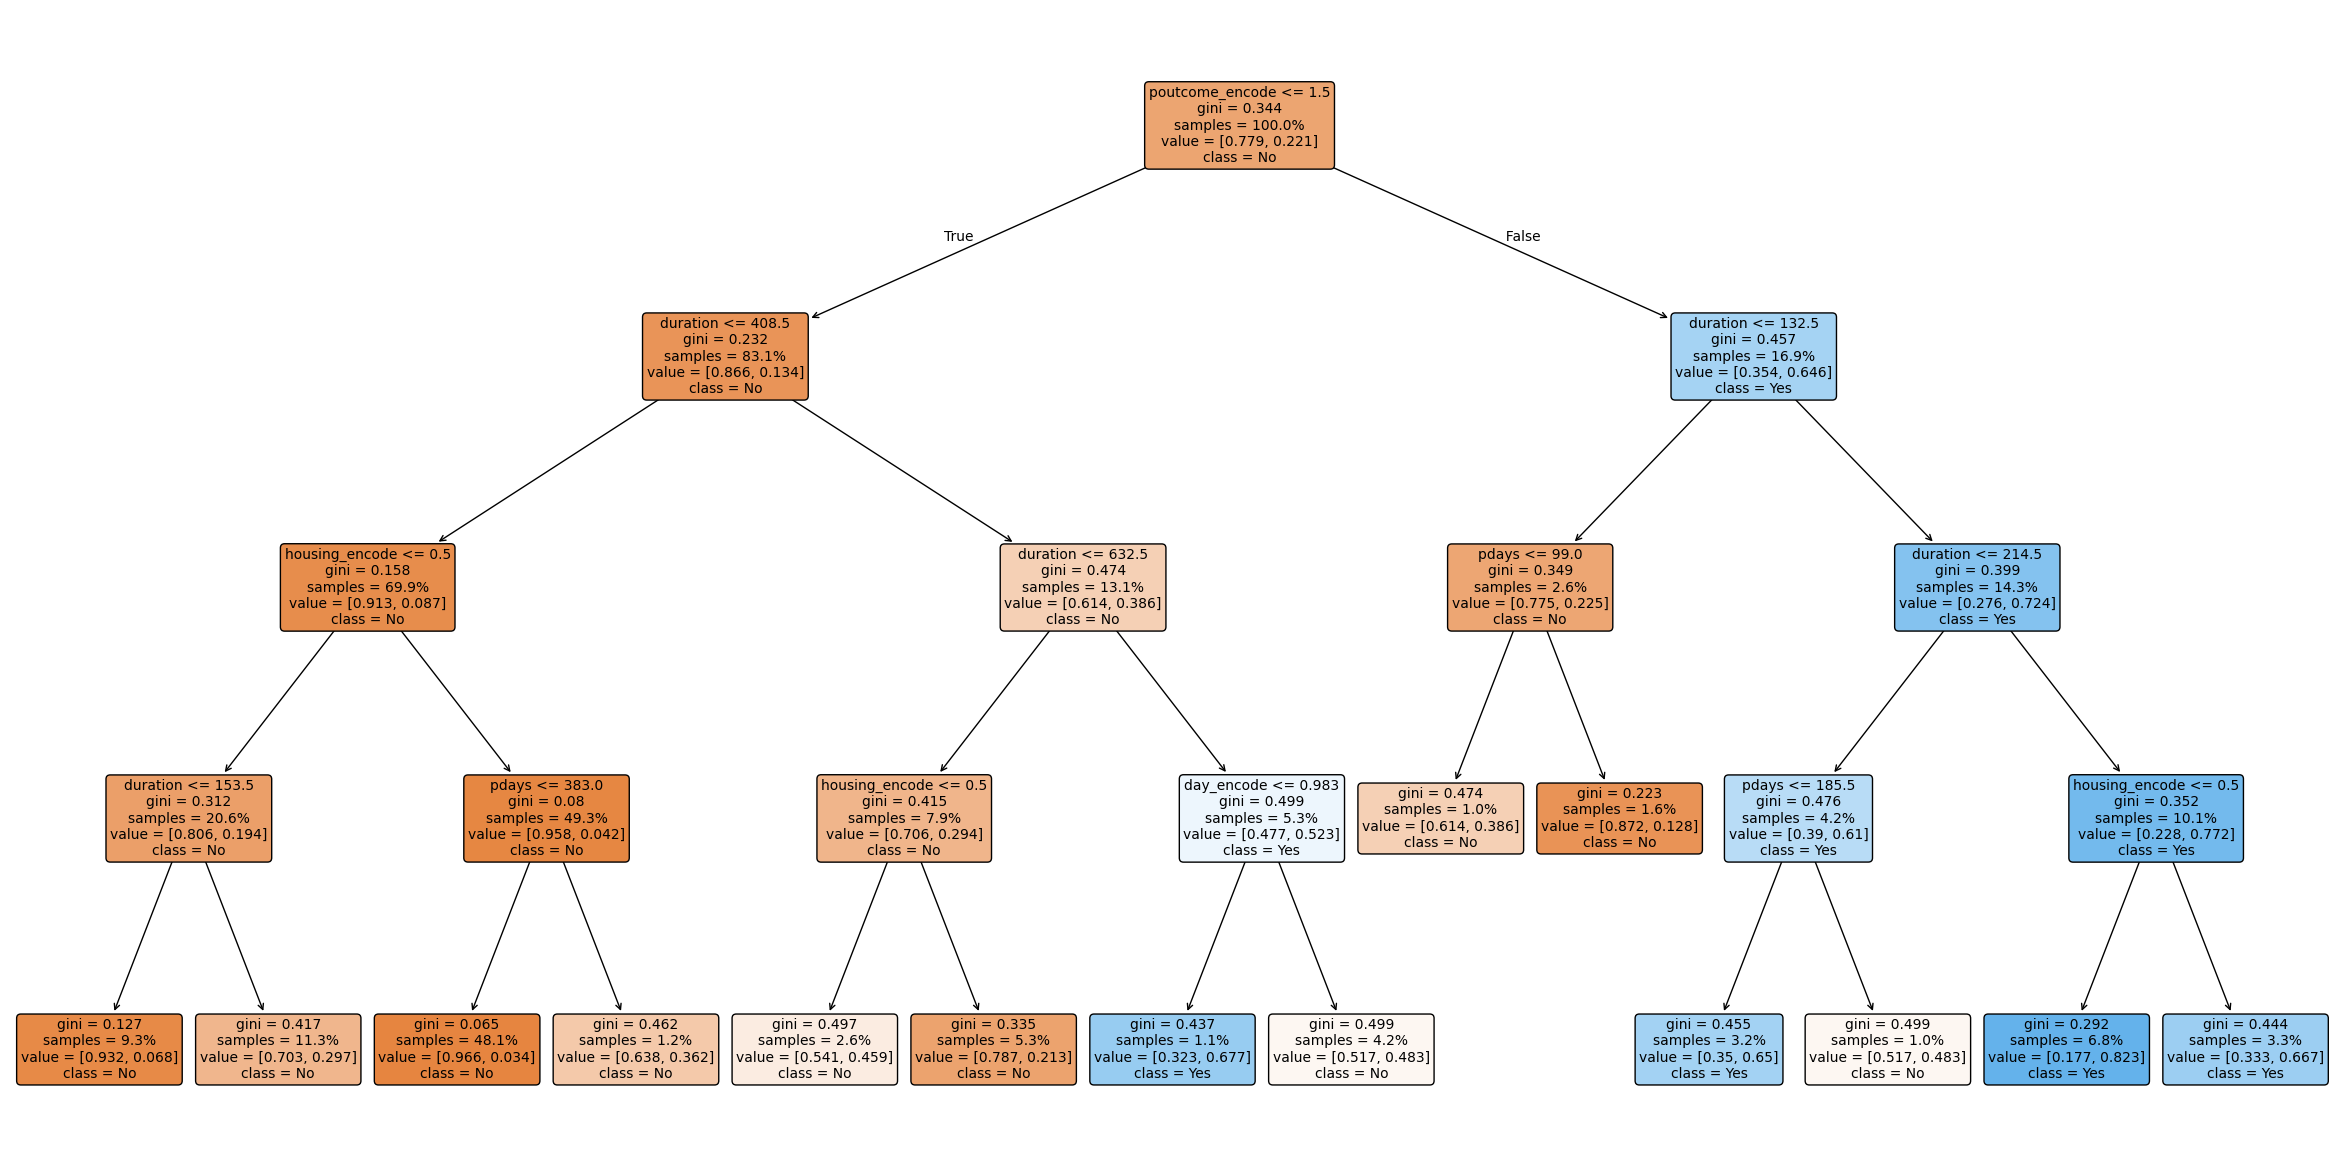

In [443]:
from sklearn.tree import plot_tree 
import matplotlib.pyplot as plt
plt.figure(figsize=(30,15))
plot_tree(
    dt,
    feature_names=X_best.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True
)
plt.show()

1. Xu hướng chung

        Các rule có Yes_ratio cao nhất (>0.6) đều liên quan đến:

        poutcome_encode > 1.5 → khách hàng đã được tiếp xúc trước, khả năng đăng ký cao

        duration dài (>132 giây) → khách hàng dành nhiều thời gian nghe tư vấn

        Thỉnh thoảng có housing_encode, pdays tham gia

        Lift cao nhất (>3) → các nhóm này gấp 3 lần khả năng đăng ký trung bình.

2. Vấn đề hiện tại với rule

        Hầu hết các rule dựa vào các biến encode hoặc hành vi tương tác như:

        poutcome_encode, duration, housing_encode, pdays, day_encode

        Chưa có rule trực tiếp liên quan tới profile khách hàng thật như: job, age, balance, loan, education

        Điều này khó triển khai marketing, vì team cần người, đặc điểm, hành vi thực tế để target.

#### Cách cải thiện

    Để tạo rule actionable:

    Chọn cluster tiềm năng từ KMeans (ví dụ cluster 3, Yes_ratio cao nhất)

    Train Decision Tree chỉ trên feature profile khách hàng thật:

In [450]:
features = ['job_encode', 'age', 'balance', 'housing_encode', 'loan_encode', 'education_encode', 'marital_encode']
X_best_fix = X_best[features]

dt_fix = DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=42)
dt_fix.fit(X_best_fix, y_best)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=42)

In [451]:
df_fix_rule_summary = extract_rules_and_test(dt_fix, X_best_fix, y_best)
display(df_fix_rule_summary)

,rule,n_samples,yes_ratio,Z_stat,p_value,lift,coverage,significant
0,housing_encode <= 0.50 AND loan_encode <= 0.50 AND balance > 134.50 AND age > 61.50,310,0.510,10.179,0.000,2.310,0.054,True
1,housing_encode > 0.50 AND age > 59.50,53,0.415,2.873,0.002,1.881,0.009,True
2,housing_encode <= 0.50 AND loan_encode <= 0.50 AND balance > 134.50 AND age <= 61.50,1320,0.413,14.184,0.000,1.871,0.231,True
3,housing_encode <= 0.50 AND loan_encode <= 0.50 AND balance <= 134.50 AND job_encode > 2.50,153,0.353,3.424,0.000,1.599,0.027,True
4,housing_encode <= 0.50 AND loan_encode > 0.50 AND balance > 946.00,50,0.280,0.934,0.175,1.269,0.009,False
5,housing_encode <= 0.50 AND loan_encode > 0.50 AND balance <= 946.00 AND age <= 36.50,57,0.211,-0.188,0.574,0.954,0.010,False
6,housing_encode > 0.50 AND age <= 59.50 AND education_encode > 1.50 AND marital_encode > 1.50,397,0.199,-1.082,0.860,0.902,0.070,False
7,housing_encode <= 0.50 AND loan_encode <= 0.50 AND balance <= 134.50 AND job_encode <= 2.50,117,0.179,-1.161,0.877,0.813,0.020,False
8,housing_encode > 0.50 AND age <= 59.50 AND education_encode <= 1.50 AND job_encode <= 0.50,628,0.151,-4.853,1.000,0.686,0.110,False
9,housing_encode > 0.50 AND age <= 59.50 AND education_encode > 1.50 AND marital_encode <= 1.50,752,0.140,-6.412,1.000,0.633,0.132,False


Khách hàng có nhà và không vay (housing=No, loan=No) với balance > 134 là nhóm Yes_ratio cao nhất → nhóm này dễ đăng ký.

Tuổi cao (>59-61) cũng làm tăng khả năng đăng ký, đặc biệt với khách hàng có nhà hoặc balance cao.

Job, education, marital cũng bắt đầu xuất hiện, cho phép phân đoạn sâu hơn.

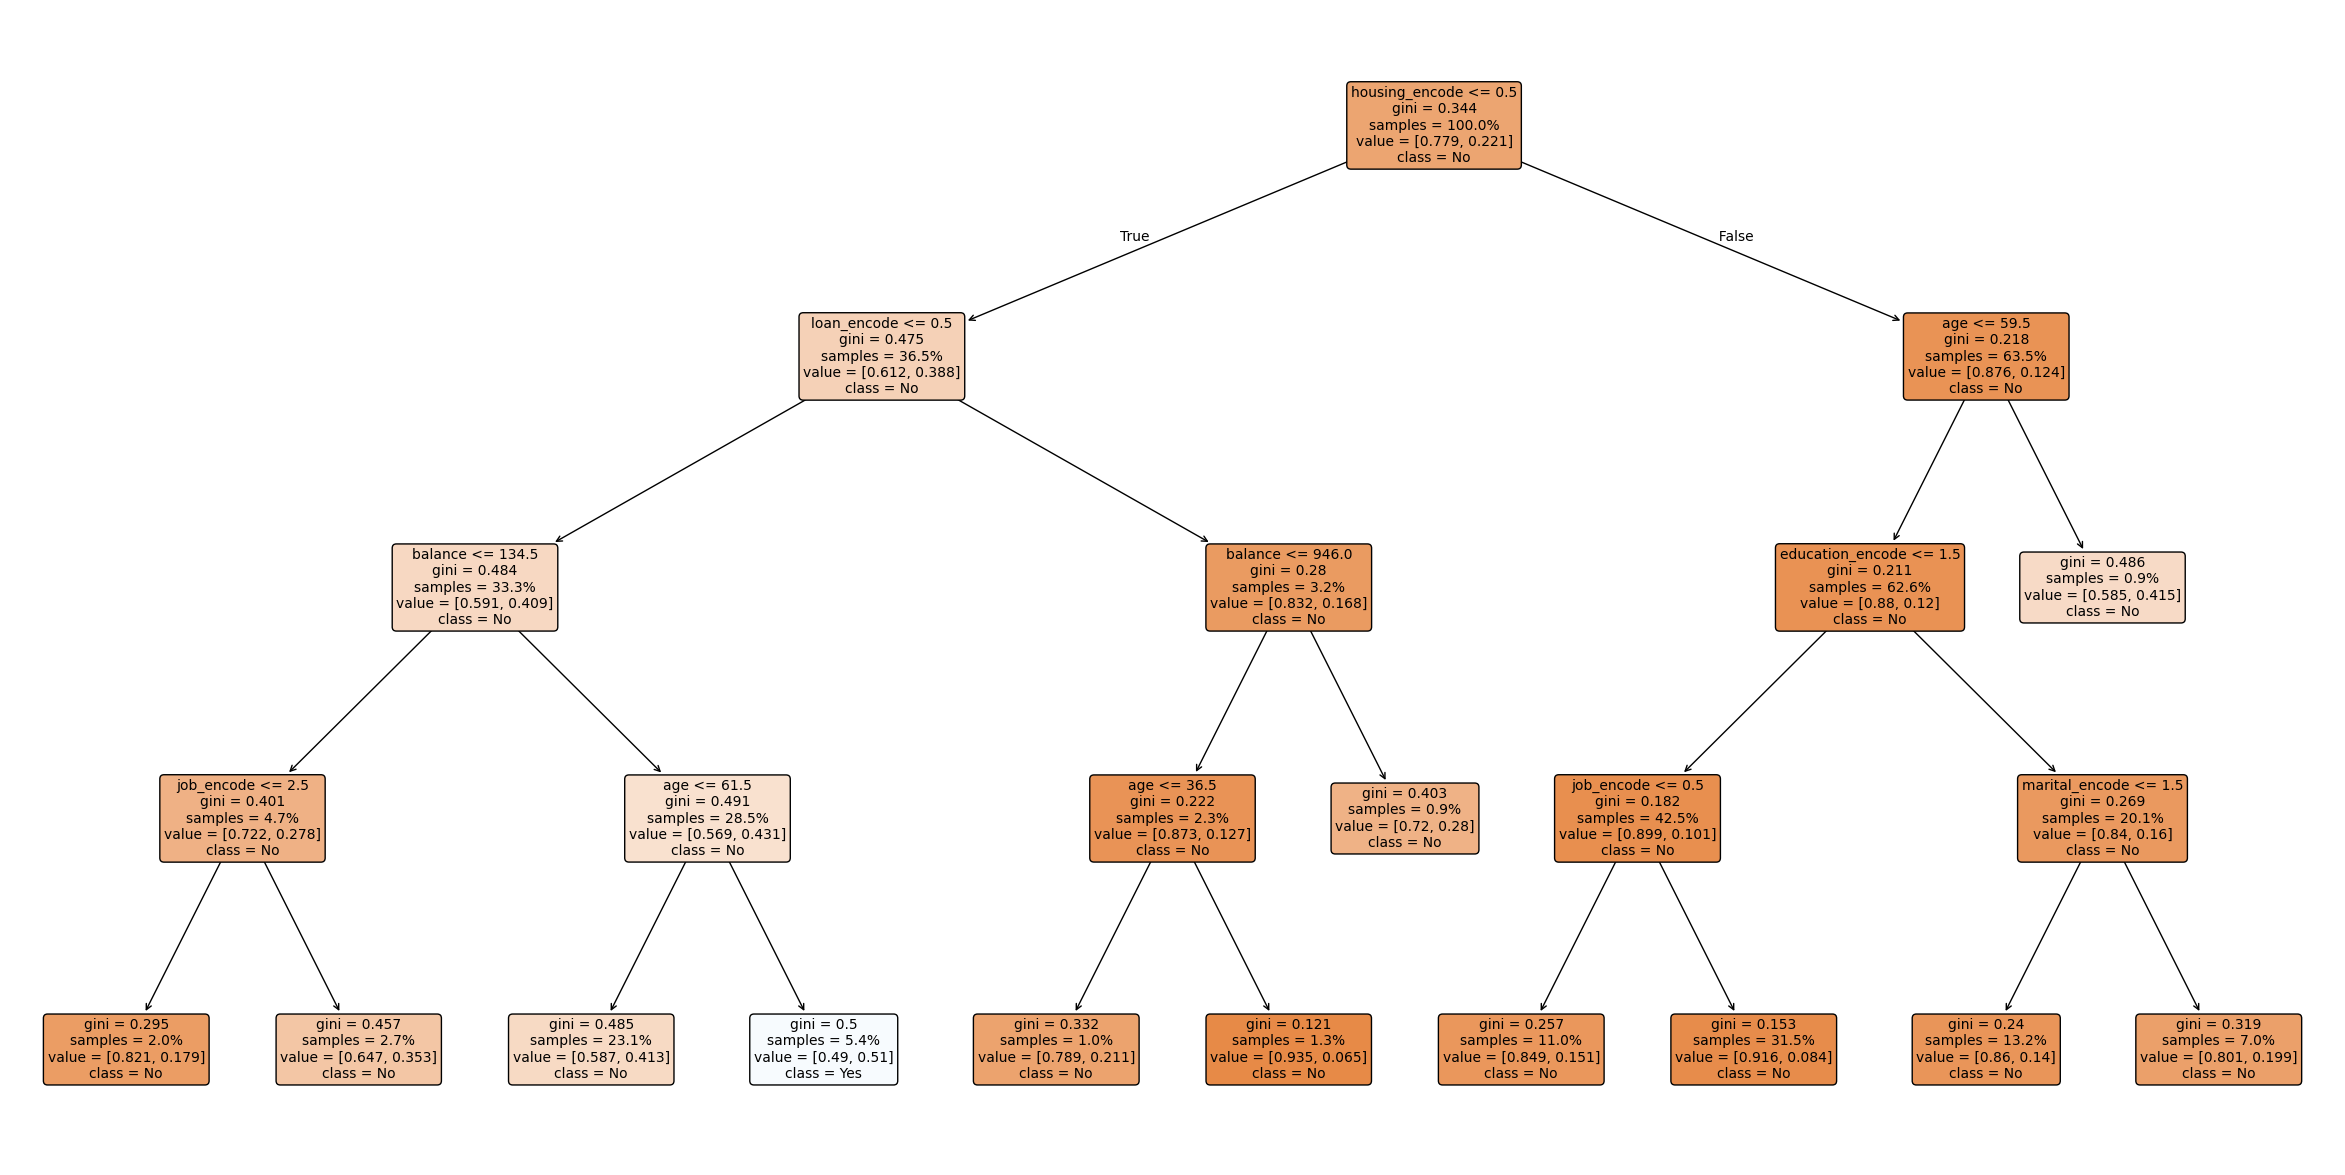

In [452]:
plt.figure(figsize=(30,15))
plot_tree(
    dt_fix,
    feature_names=X_best_fix.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True
)
plt.show()

SUMMARY 

    Rule tiềm năng để áp dụng marketing: các nhóm housing, loan, balance, age, job với Yes_ratio ≥ 0.35 và significant=True.

    Đây là pattern khách hàng thật, không chỉ dựa vào hành vi tương tác (duration, poutcome).

    Tiếp cận chiến dịch: target các rule top đầu → nhóm này có lift cao hơn 1.5-2.3 lần so với trung bình, khả năng ROI cao.